In [1]:
!pip install -U scikit-learn

In [2]:
pip install pandas openpyxl

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd

In [5]:
import matplotlib.pyplot as plt

In [6]:
file_path = '/content/drive/MyDrive/AI Property Booking Concierge/dataset.csv'
df = pd.read_csv(file_path)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [8]:
df.head(
)

,id,title,description,property_type,bedrooms,bathrooms,price_per_night,square_feet,amenities,city,state,zipcode,country,occupancy_max,rating,reviews_count,availability_start,availability_end,host_id,created_at
0,1634f9de-786c-4810-a552-604f378bc84b,5BR Loft in Miami,Spacious layout ideal for groups and longer st...,Loft,5,5,727,2085,balcony;dryer;gym;kitchen;washer,Miami,FL,32520,USA,10,3.64,47,2025-11-23,2025-12-04,h_1434,2024-12-06T15:35:49
1,2a9e8a58-969c-46e4-8ce1-0a14cb3fde3d,3BR House in Somerville,Cozy retreat with fully equipped kitchen and w...,House,3,3,411,1284,dryer;fireplace;parking;pool;wheelchair_access,Somerville,MA,6552,USA,6,3.82,916,2025-11-02,2025-11-05,h_2519,2025-03-09T15:35:49
2,f8b59c5e-ed67-4d69-81d6-e6e35634bc5e,2BR Duplex in Fort Lauderdale,Quiet residential area with quick access to do...,Duplex,2,2,245,722,ac;balcony;elevator;heating;kitchen;pet_friend...,Fort Lauderdale,FL,32750,USA,4,4.53,597,2025-09-30,2025-10-05,h_2654,2025-03-09T15:35:49
3,684d1ee5-369a-4ce4-8223-53344dc3bed1,5BR Studio in Roswell,Charming home with a private garden and outdoo...,Studio,5,5,359,2527,dryer;fireplace;heating;kitchen;washer;wheelch...,Roswell,GA,32803,USA,10,4.35,59,2025-11-18,2025-11-26,h_5422,2024-10-27T15:35:49
4,5f189ec6-199c-4d52-b7c1-f45a699f2687,5BR Studio in Elizabeth,"Walkable location with shops, cafes, and night...",Studio,5,5,522,3389,ac;elevator;pet_friendly;pool;wifi,Elizabeth,NJ,8084,USA,10,3.90,889,2025-10-30,2025-11-04,h_9179,2025-03-01T15:35:49


In [9]:
print(df.columns)

Index(['id', 'title', 'description', 'property_type', 'bedrooms', 'bathrooms',
       'price_per_night', 'square_feet', 'amenities', 'city', 'state',
       'zipcode', 'country', 'occupancy_max', 'rating', 'reviews_count',
       'availability_start', 'availability_end', 'host_id', 'created_at'],
      dtype='object')


In [10]:
pivot_table = pd.pivot_table(
    df,
    index=["city"],
    columns="property_type",
    values="id",
    aggfunc="count",
    fill_value=0,
    margins=True,
    margins_name="Grand Total"
)

print(pivot_table)

property_type  Apartment  Bungalow  Condo  Cottage  Duplex  House  Loft  \
city                                                                      
Akron                 13        10     19       17      12     17     8   
Albany                10        11      9       13      13     15     9   
Alexandria            15        12      9       22      11     14    13   
Allentown             13        16      7       22      13     12    12   
Alpharetta            13        14     13       12      14     11    16   
...                  ...       ...    ...      ...     ...    ...   ...   
Worcester             11        11     11        6      11     10    14   
Yonkers               13        17      7       14      10     18    18   
York                  13        15     12       16      13     11     7   
Youngstown             9        12     12       12      10     13    14   
Grand Total         2537      2452   2550     2573    2475   2538  2481   

property_type  Studio  T

In [11]:
pivot_table_one = pd.pivot_table(
    df,
    index="city",
    columns="property_type",
    values="id",
    aggfunc="count",
    fill_value=0,
    margins=True,
    margins_name="Grand Total"
)
print(pivot_table_one)

property_type  Apartment  Bungalow  Condo  Cottage  Duplex  House  Loft  \
city                                                                      
Akron                 13        10     19       17      12     17     8   
Albany                10        11      9       13      13     15     9   
Alexandria            15        12      9       22      11     14    13   
Allentown             13        16      7       22      13     12    12   
Alpharetta            13        14     13       12      14     11    16   
...                  ...       ...    ...      ...     ...    ...   ...   
Worcester             11        11     11        6      11     10    14   
Yonkers               13        17      7       14      10     18    18   
York                  13        15     12       16      13     11     7   
Youngstown             9        12     12       12      10     13    14   
Grand Total         2537      2452   2550     2573    2475   2538  2481   

property_type  Studio  T

In [12]:
X = df[
    [
        "bedrooms",
        "bathrooms",
        "price_per_night",
        "square_feet",
        "occupancy_max",
        "rating",
        "reviews_count"
    ]
]

y = df["property_type"]
label_encoder = LabelEncoder()
y= label_encoder.fit_transform(y)

In [13]:
X_train,X_temp,y_train,y_temp = train_test_split(
    X,
    y,
    test_size = 0.25,
    random_state = 42,
    stratify = y,
    shuffle = True

)

In [14]:
X_dev,X_test,y_dev,y_test = train_test_split(
    X_temp,
    y_temp,
    test_size = 0.60,
    random_state = 42,
    stratify = y_temp,
    shuffle = True

)

In [15]:
print("train size:", X_train.shape[0])
print("dev size:", X_dev.shape[0])
print("test size:", X_test.shape[0])

print("\nTrain percentage:", round(len(X_train)/len(df)*100,2),"%")
print("Dev percentage:", round(len(X_dev)/len(df)*100,2),"%")
print("Test percentage:", round(len(X_test)/len(df)*100,2),"%")

train size: 18750
dev size: 2500
test size: 3750

Train percentage: 75.0 %
Dev percentage: 10.0 %
Test percentage: 15.0 %


In [16]:
print("\nTrain class distribution:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())
print("\nDev class distribution:")
print(pd.Series(y_dev).value_counts(normalize=True).sort_index())
print("\nTest class distribution:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())


Train class distribution:
0    0.101493
1    0.098080
2    0.101973
3    0.102933
4    0.098987
5    0.101493
6    0.099253
7    0.100587
8    0.096693
9    0.098507
Name: proportion, dtype: float64

Dev class distribution:
0    0.1016
1    0.0980
2    0.1020
3    0.1028
4    0.0992
5    0.1016
6    0.0992
7    0.1004
8    0.0968
9    0.0984
Name: proportion, dtype: float64

Test class distribution:
0    0.101333
1    0.098133
2    0.102133
3    0.102933
4    0.098933
5    0.101600
6    0.099200
7    0.100533
8    0.096533
9    0.098667
Name: proportion, dtype: float64


In [17]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=5000))
])

In [18]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may n

In [19]:
train_preds = model.predict(X_train)
dev_preds = model.predict(X_dev)
test_preds = model.predict(X_test)

In [20]:
train_acc = accuracy_score(y_train, train_preds)
dev_acc = accuracy_score(y_dev, dev_preds)
test_acc = accuracy_score(y_test, test_preds)

In [21]:
train_error = 1 - train_acc
dev_error = 1 - dev_acc
test_error = 1 - test_acc

In [22]:
print("\n========== ACCURACY RESULTS ==========")

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Dev Accuracy: {dev_acc:.3f}")
print(f"Test Accuracy: {test_acc:.4f}")

print("\n========== ERROR RESULTS ============")

print(f"Train Error: {train_error:.4f}")
print(f"Dev Error: {dev_error:.4f}")
print(f"Test Error: {test_error:.4f}")


========== ACCURACY RESULTS ==========
Train Accuracy: 0.109
Dev Accuracy: 0.107
Test Accuracy: 0.1048

========== ERROR RESULTS ============
Train Error: 0.8913
Dev Error: 0.8932
Test Error: 0.8952


In [23]:
bias_threshold = 0.30
variance_gap_threshold = 0.10

In [24]:
if train_error > bias_threshold:
  print("Diagnosis: HIGH BIAS / UNDERFITTING")
  print("Reason: Training error is high.")
  print("Meaning: Model is too simple or features are weak.")

elif (dev_error - train_error) > variance_gap_threshold:
  print("Diagnosis: HIGH VARIANCE / OVERFITTING")
  print("Reason: Dev error is much higher than train error.")
  print("Meaning: Model memorized training data but failed to generalize.")

else:
    print("Diagnosis: Bias and variance are reasonably balanced.")
    print("Reason: Train and dev errors are close.")

Diagnosis: HIGH BIAS / UNDERFITTING
Reason: Training error is high.
Meaning: Model is too simple or features are weak.


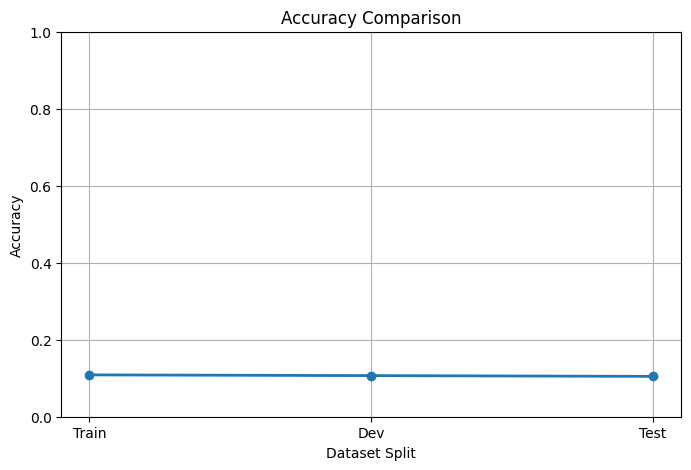

In [25]:
datasets = ["Train", "Dev", "Test"]
accuracies = [train_acc, dev_acc, test_acc]
errors = [train_error, dev_error, test_error]

plt.figure(figsize=(8, 5))
plt.plot(datasets, accuracies, marker="o", linewidth=2)
plt.title("Accuracy Comparison")
plt.xlabel("Dataset Split")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

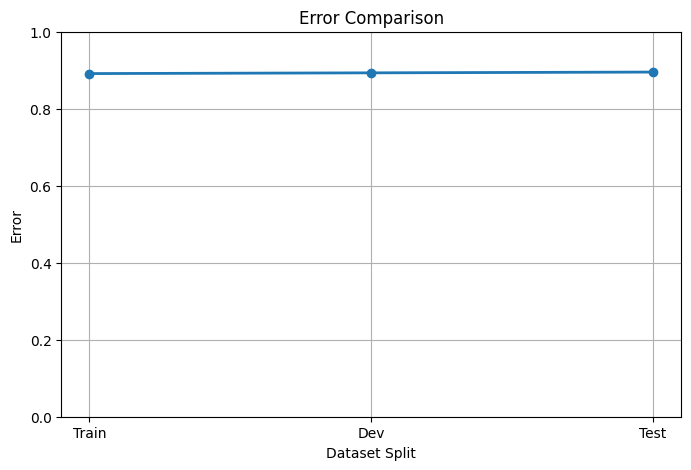

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(datasets, errors, marker="o", linewidth=2)
plt.title("Error Comparison")
plt.xlabel("Dataset Split")
plt.ylabel("Error")
plt.ylim(0, 1)
plt.grid(True)
plt.show()


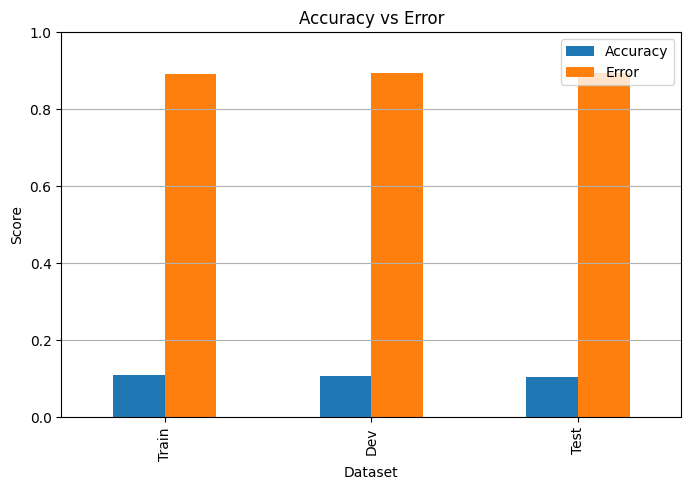

In [27]:
results_df = pd.DataFrame({
    "Dataset": datasets,
    "Accuracy": accuracies,
    "Error": errors
})

results_df.plot(
    x="Dataset",
    y=["Accuracy", "Error"],
    kind="bar",
    figsize=(8, 5)
)

plt.title("Accuracy vs Error")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

<Figure size 1000x1000 with 0 Axes>

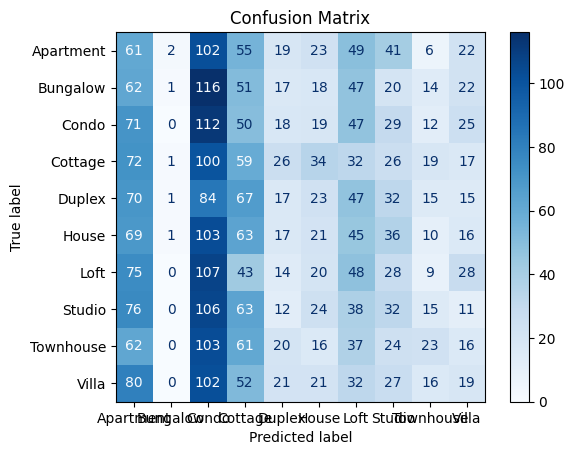

In [28]:
cm = confusion_matrix(y_test, test_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(10,10))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()